In [1]:
# load the full modeling dataframe with keys
import pandas as pd
import numpy as np
from pathlib import Path

DATA_PATH = Path("../data/clean/daily_stock_optimal_bucket_modeling_with_fred.parquet")
df = pd.read_parquet(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

print(df.shape)
print(df[["symbol", "date", "optimal_bucket"]].head())

(41266, 88)
  symbol       date optimal_bucket
0   AAPL 2006-01-03        OTM5_30
1   AAPL 2006-01-04        OTM5_30
2   AAPL 2006-01-05        OTM5_30
3   AAPL 2006-01-06        OTM5_30
4   AAPL 2006-01-09        OTM5_30


### Class distribution before changes

In [2]:
# Check current bucket distribution before change
print("Original optimal_bucket distribution:")
print(df["optimal_bucket"].value_counts())
# Replace selected bucket labels
bucket_map = {
    "OTM10_60": "OTM10_60_90",
    "OTM10_90": "OTM10_60_90",
    "OTM5_60": "OTM5_60_90",
    "OTM5_90": "OTM5_60_90"
}

df["optimal_bucket"] = df["optimal_bucket"].replace(bucket_map)

# Check updated distribution
print("\nUpdated optimal_bucket distribution:")
print(df["optimal_bucket"].value_counts())

Original optimal_bucket distribution:
optimal_bucket
ATM_90      15324
ATM_60       6470
ATM_30       4893
OTM5_30      3813
OTM10_30     3463
OTM5_60      2602
OTM10_90     2580
OTM5_90      1367
OTM10_60      754
Name: count, dtype: int64

Updated optimal_bucket distribution:
optimal_bucket
ATM_90         15324
ATM_60          6470
ATM_30          4893
OTM5_60_90      3969
OTM5_30         3813
OTM10_30        3463
OTM10_60_90     3334
Name: count, dtype: int64


### Encode Target variable

In [3]:
# encode the target and prepare features
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()
df["target"] = target_encoder.fit_transform(df["optimal_bucket"])

print(dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))

{'ATM_30': np.int64(0), 'ATM_60': np.int64(1), 'ATM_90': np.int64(2), 'OTM10_30': np.int64(3), 'OTM10_60_90': np.int64(4), 'OTM5_30': np.int64(5), 'OTM5_60_90': np.int64(6)}


### Train/test/Split

In [4]:
# Split by date before building sequences
train_df = df[df["date"] < "2022-01-01"].copy()
val_df = df[(df["date"] >= "2022-01-01") & (df["date"] < "2024-01-01")].copy()
test_df = df[df["date"] >= "2024-01-01"].copy()

print(train_df.shape, val_df.shape, test_df.shape)

(33736, 89) (5010, 89) (2520, 89)


In [5]:
# ---------------------------------------------
# Feature selection on TRAIN ONLY
# ---------------------------------------------
exclude_cols = [
    "symbol",
    "date",
    "fiscalDateEnding",
    "optimal_bucket",
    "target"
]

X_rf = train_df.drop(columns=[c for c in exclude_cols if c in train_df.columns]).copy()
X_rf = X_rf.select_dtypes(include=["number"]).copy()
y_rf = train_df["target"].copy()

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced_subsample"
)

rf.fit(X_rf, y_rf)

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_rf.columns
).sort_values(ascending=False)

top_35_features = feature_importance.head(35)

print("Top 35 features:")

Top 35 features:


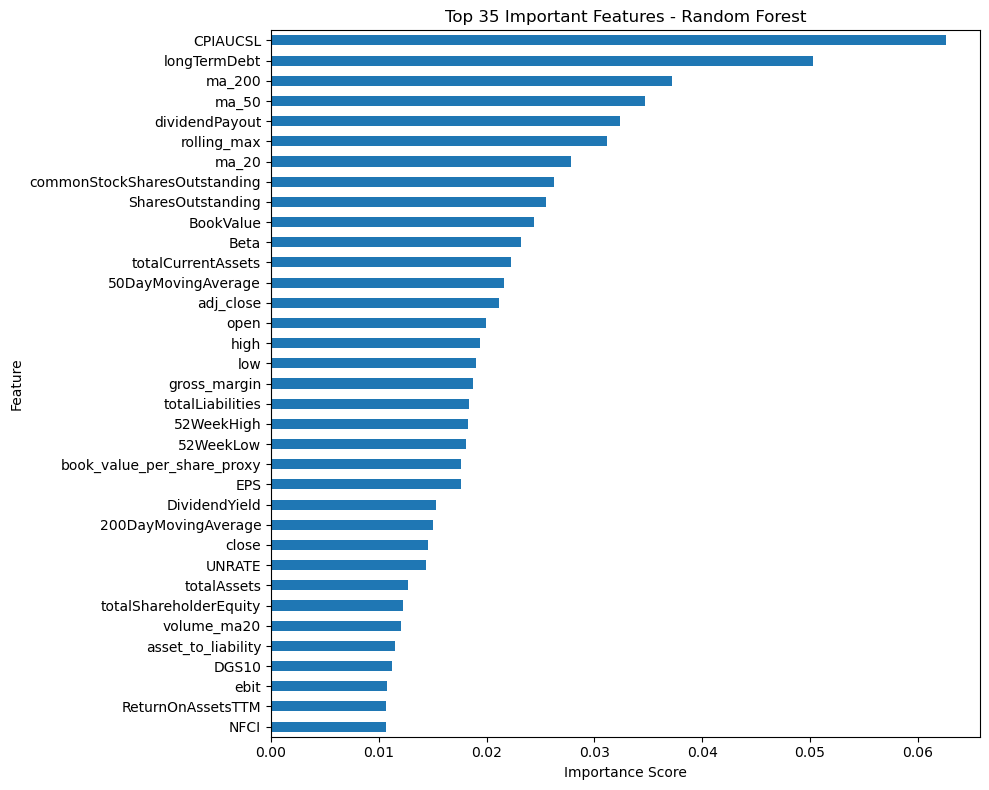

In [6]:
# --------------------------------------------------
# Plot top 35 features
# --------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
top_35_features.sort_values().plot(kind="barh")
plt.title("Top 35 Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
keep_cols = ["symbol", "date", "target"] + top_35_features.index.tolist()

train_df = train_df[keep_cols].copy()
val_df = val_df[keep_cols].copy()
test_df = test_df[keep_cols].copy()

feature_cols = top_35_features.index.tolist()

### Standard scaling

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(train_df[feature_cols])

train_df[feature_cols] = scaler.transform(train_df[feature_cols])
val_df[feature_cols] = scaler.transform(val_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

### Prepare input sequences for the model

In [10]:
# Build rolling sequences per symbol ( use past 30 days to predict the label on day 30)

SEQ_LEN = 50

def build_sequences(panel_df, feature_cols, target_col="target", seq_len=50):
    X_seq = []
    y_seq = []

    for sym, grp in panel_df.groupby("symbol"):
        grp = grp.sort_values("date").reset_index(drop=True)

        X_vals = grp[feature_cols].values
        y_vals = grp[target_col].values

        if len(grp) < seq_len:
            continue

        for i in range(seq_len - 1, len(grp)):
            X_seq.append(X_vals[i - seq_len + 1:i + 1])
            y_seq.append(y_vals[i])

    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.int64)

In [11]:
# Now create train/val/test sequences

X_train_seq, y_train_seq = build_sequences(train_df, feature_cols, seq_len=SEQ_LEN)
X_val_seq, y_val_seq = build_sequences(val_df, feature_cols, seq_len=SEQ_LEN)
X_test_seq, y_test_seq = build_sequences(test_df, feature_cols, seq_len=SEQ_LEN)

print("Train sequences:", X_train_seq.shape, y_train_seq.shape)
print("Val sequences:", X_val_seq.shape, y_val_seq.shape)
print("Test sequences:", X_test_seq.shape, y_test_seq.shape)

Train sequences: (33246, 50, 35) (33246,)
Val sequences: (4520, 50, 35) (4520,)
Test sequences: (2030, 50, 35) (2030,)


### Imbalance corrections

In [12]:
# optionally rebalnce train split

train_seq_df = pd.DataFrame({"target": y_train_seq})
print(train_seq_df["target"].value_counts().sort_index())

target
0     4298
1     6141
2    12459
3     3072
4      713
5     3630
6     2933
Name: count, dtype: int64


In [13]:
target_counts = {
    2: 9000,
    4: 1500,
    6: 2200
}

balanced_indices = []

for cls, idx in train_seq_df.groupby("target").groups.items():
    idx = np.array(list(idx))
    n_current = len(idx)

    if cls in target_counts:
        n_target = target_counts[cls]

        if n_target < n_current:
            idx_bal = np.random.RandomState(42).choice(idx, size=n_target, replace=False)
        elif n_target > n_current:
            idx_bal = np.random.RandomState(42).choice(idx, size=n_target, replace=True)
        else:
            idx_bal = idx
    else:
        idx_bal = idx

    balanced_indices.extend(idx_bal.tolist())

balanced_indices = np.array(balanced_indices)

X_train_seq_bal = X_train_seq[balanced_indices]
y_train_seq_bal = y_train_seq[balanced_indices]

print(X_train_seq_bal.shape, y_train_seq_bal.shape)
print(pd.Series(y_train_seq_bal).value_counts().sort_index())

(29841, 50, 35) (29841,)
0    4298
1    6141
2    9000
3    3072
4    1500
5    3630
6    2200
Name: count, dtype: int64


In [14]:
# Compute class weights
from sklearn.utils.class_weight import compute_class_weight

classes_bal = np.sort(np.unique(y_train_seq_bal))
class_weights_bal = compute_class_weight(
    class_weight="balanced",
    classes=classes_bal,
    y=y_train_seq_bal
)

class_weight_dict_bal = dict(zip(classes_bal, class_weights_bal))
print(class_weight_dict_bal)

{np.int64(0): np.float64(0.99185667752443), np.int64(1): np.float64(0.6941866145578895), np.int64(2): np.float64(0.4736666666666667), np.int64(3): np.float64(1.3876953125), np.int64(4): np.float64(2.842), np.int64(5): np.float64(1.1743801652892563), np.int64(6): np.float64(1.9377272727272727)}


In [15]:
# Create pytorch datasets

import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "past_values": self.X[idx],
            "target": self.y[idx]
        }

train_dataset = TimeSeriesDataset(X_train_seq_bal, y_train_seq_bal)
val_dataset = TimeSeriesDataset(X_val_seq, y_val_seq)
test_dataset = TimeSeriesDataset(X_test_seq, y_test_seq)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [16]:
# import pretrained source model
from transformers import PatchTSTConfig, PatchTSTForClassification, PatchTSTForPrediction
import torch
import torch.nn as nn
import numpy as np

PRETRAINED_CKPT = "ibm-granite/granite-timeseries-patchtst"

In [17]:
# Load pretrained PatchTST source checkpoint
source_model = PatchTSTForPrediction.from_pretrained(PRETRAINED_CKPT)

print("Loaded pretrained checkpoint successfully")

Loading weights:   0%|          | 0/72 [00:00<?, ?it/s]

Loaded pretrained checkpoint successfully


In [18]:
from transformers import PatchTSTConfig, PatchTSTForClassification
import numpy as np

num_classes = len(np.unique(y_train_seq_bal))
num_input_channels = X_train_seq_bal.shape[2]

clf_config = PatchTSTConfig(
    num_input_channels=num_input_channels,   # keep your own feature count
    context_length=SEQ_LEN,                  # keep your own sequence length
    patch_length=source_model.config.patch_length,
    patch_stride=source_model.config.patch_stride,
    num_targets=num_classes,
    d_model=source_model.config.d_model,
    num_attention_heads=source_model.config.num_attention_heads,
    num_hidden_layers=source_model.config.num_hidden_layers,
    ffn_dim=source_model.config.ffn_dim,
    dropout=source_model.config.dropout,
    head_dropout=source_model.config.head_dropout,
    norm_type=source_model.config.norm_type,
    activation_function=source_model.config.activation_function,
    attention_dropout=source_model.config.attention_dropout,
    ff_dropout=source_model.config.ff_dropout,
    positional_dropout=source_model.config.positional_dropout,
    path_dropout=source_model.config.path_dropout,
    pre_norm=source_model.config.pre_norm,
    positional_encoding_type=source_model.config.positional_encoding_type,
    use_cls_token=source_model.config.use_cls_token,
    share_embedding=source_model.config.share_embedding,
    channel_attention=source_model.config.channel_attention,
    bias=source_model.config.bias,
)
clf_model = PatchTSTForClassification(clf_config)

print("Rebuilt classification model with pretrained backbone dimensions")

Rebuilt classification model with pretrained backbone dimensions


In [19]:
source_state = source_model.state_dict()
target_state = clf_model.state_dict()

loaded_keys = []
skipped_keys = []

for k in target_state.keys():
    if k in source_state and source_state[k].shape == target_state[k].shape:
        target_state[k] = source_state[k]
        loaded_keys.append(k)
    else:
        skipped_keys.append(k)

clf_model.load_state_dict(target_state)

print("Loaded pretrained weights:", len(loaded_keys))
print("Skipped:", len(skipped_keys))
print("First 20 skipped keys:", skipped_keys[:20])

Loaded pretrained weights: 69
Skipped: 3
First 20 skipped keys: ['model.encoder.positional_encoder.position_enc', 'head.linear.weight', 'head.linear.bias']


In [20]:
print(source_model.config)

PatchTSTConfig {
  "activation_function": "gelu",
  "architectures": [
    "PatchTSTForPrediction"
  ],
  "attention_dropout": 0.0,
  "bias": true,
  "channel_attention": false,
  "channel_consistent_masking": false,
  "context_length": 512,
  "d_model": 128,
  "distribution_output": "student_t",
  "do_mask_input": null,
  "dropout": 0.2,
  "dtype": "float32",
  "ff_dropout": 0.0,
  "ffn_dim": 512,
  "head_dropout": 0.2,
  "init_std": 0.02,
  "loss": "mse",
  "mask_input": null,
  "mask_type": "random",
  "mask_value": 0,
  "model_type": "patchtst",
  "norm_eps": 1e-05,
  "norm_type": "batchnorm",
  "num_attention_heads": 16,
  "num_forecast_mask_patches": [
    2
  ],
  "num_hidden_layers": 3,
  "num_input_channels": 7,
  "num_parallel_samples": 100,
  "num_targets": 1,
  "output_range": null,
  "patch_length": 12,
  "patch_stride": 12,
  "path_dropout": 0.0,
  "pooling_type": null,
  "positional_dropout": 0.0,
  "positional_encoding_type": "sincos",
  "pre_norm": true,
  "prediction_

In [21]:
print("Source state keys sample:")
print(list(source_state.keys())[:30])

print("\nTarget state keys sample:")
print(list(target_state.keys())[:30])

Source state keys sample:
['model.encoder.embedder.input_embedding.weight', 'model.encoder.embedder.input_embedding.bias', 'model.encoder.positional_encoder.cls_token', 'model.encoder.positional_encoder.position_enc', 'model.encoder.layers.0.self_attn.k_proj.weight', 'model.encoder.layers.0.self_attn.k_proj.bias', 'model.encoder.layers.0.self_attn.v_proj.weight', 'model.encoder.layers.0.self_attn.v_proj.bias', 'model.encoder.layers.0.self_attn.q_proj.weight', 'model.encoder.layers.0.self_attn.q_proj.bias', 'model.encoder.layers.0.self_attn.out_proj.weight', 'model.encoder.layers.0.self_attn.out_proj.bias', 'model.encoder.layers.0.norm_sublayer1.batchnorm.weight', 'model.encoder.layers.0.norm_sublayer1.batchnorm.bias', 'model.encoder.layers.0.norm_sublayer1.batchnorm.running_mean', 'model.encoder.layers.0.norm_sublayer1.batchnorm.running_var', 'model.encoder.layers.0.norm_sublayer1.batchnorm.num_batches_tracked', 'model.encoder.layers.0.ff.0.weight', 'model.encoder.layers.0.ff.0.bias', 

In [22]:
print("Loaded pretrained weights:", len(loaded_keys))
print("Skipped:", len(skipped_keys))
print("First 30 skipped keys:", skipped_keys[:30])

Loaded pretrained weights: 69
Skipped: 3
First 30 skipped keys: ['model.encoder.positional_encoder.position_enc', 'head.linear.weight', 'head.linear.bias']


In [23]:
# training setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
clf_model.to(device)

weights_tensor = torch.tensor(
    [class_weight_dict_bal[c] for c in range(num_classes)],
    dtype=torch.float32,
    device=device
)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)

print("Training setup ready")

Training setup ready


In [24]:
# Freeze backbone train only classification head
for name, param in clf_model.named_parameters():
    param.requires_grad = False

for name, param in clf_model.named_parameters():
    if "head" in name:
        param.requires_grad = True

trainable_params = [name for name, p in clf_model.named_parameters() if p.requires_grad]
print("Trainable params:")
print(trainable_params)

Trainable params:
['head.linear.weight', 'head.linear.bias']


In [45]:
# optimizer for head-only training
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, clf_model.parameters()),
    lr=5e-5,
    weight_decay=5e-5
)

In [46]:
# define evaluation helper
from sklearn.metrics import f1_score
import torch
import numpy as np

def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    preds, targets = [], []

    with torch.no_grad():
        for batch in loader:
            x = batch["past_values"].to(device)
            y = batch["target"].to(device)

            outputs = model(past_values=x)
            logits = outputs.prediction_logits

            loss = criterion(logits, y)
            total_loss += loss.item()

            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            targets.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(targets, preds, average="macro", zero_division=0)
    return avg_loss, macro_f1

In [47]:
# define training helper
def train_patchtst_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=12,
    patience=3
):
    best_val_f1 = -1
    best_state = None
    patience_counter = 0

    train_losses, val_losses = [], []
    train_f1s, val_f1s = [], []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        train_preds, train_targets = [], []

        for batch in train_loader:
            x = batch["past_values"].to(device)
            y = batch["target"].to(device)

            optimizer.zero_grad()

            outputs = model(past_values=x)
            logits = outputs.prediction_logits

            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            train_preds.extend(torch.argmax(logits, dim=1).detach().cpu().numpy())
            train_targets.extend(y.cpu().numpy())

        avg_train_loss = total_train_loss / len(train_loader)
        train_macro_f1 = f1_score(train_targets, train_preds, average="macro", zero_division=0)

        val_loss, val_macro_f1 = evaluate_model(model, val_loader, criterion, device)

        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        train_f1s.append(train_macro_f1)
        val_f1s.append(val_macro_f1)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | Train F1: {train_macro_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val F1: {val_macro_f1:.4f}"
        )

        if val_macro_f1 > best_val_f1:
            best_val_f1 = val_macro_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered")
            break

    return {
        "best_val_f1": best_val_f1,
        "best_state": best_state,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_f1s": train_f1s,
        "val_f1s": val_f1s,
    }

In [48]:
result_probe = train_patchtst_model(
    model=clf_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=15,
    patience=4
)

clf_model.load_state_dict(result_probe["best_state"])

print("Head-only training complete")
print("Best Val Macro F1:", result_probe["best_val_f1"])

Epoch 1/15 | Train Loss: 0.6020 | Train F1: 0.7461 | Val Loss: 4.5472 | Val F1: 0.1578
Epoch 2/15 | Train Loss: 0.5710 | Train F1: 0.7592 | Val Loss: 5.0650 | Val F1: 0.1566
Epoch 3/15 | Train Loss: 0.5370 | Train F1: 0.7716 | Val Loss: 5.5145 | Val F1: 0.1471
Epoch 4/15 | Train Loss: 0.5092 | Train F1: 0.7851 | Val Loss: 5.5946 | Val F1: 0.1556
Epoch 5/15 | Train Loss: 0.4820 | Train F1: 0.7957 | Val Loss: 5.6704 | Val F1: 0.1500
Early stopping triggered
Head-only training complete
Best Val Macro F1: 0.15778291696144434


In [50]:
# unfreeze full model
for param in clf_model.parameters():
    param.requires_grad = True

print("All layers unfrozen")

All layers unfrozen


In [62]:
# optimizer for full training
optimizer = torch.optim.AdamW(
    clf_model.parameters(),
    lr=1e-4,
    weight_decay=5e-4
)

In [63]:
# full fine-tuning
result_ft = train_patchtst_model(
    model=clf_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10,
    patience=4
)

clf_model.load_state_dict(result_ft["best_state"])

print("Full fine-tuning complete")
print("Best Val Macro F1:", result_ft["best_val_f1"])

Epoch 1/10 | Train Loss: 0.5315 | Train F1: 0.7711 | Val Loss: 5.3758 | Val F1: 0.1346
Epoch 2/10 | Train Loss: 0.4948 | Train F1: 0.7926 | Val Loss: 5.4735 | Val F1: 0.1381
Epoch 3/10 | Train Loss: 0.4555 | Train F1: 0.8067 | Val Loss: 6.0960 | Val F1: 0.1316
Epoch 4/10 | Train Loss: 0.4295 | Train F1: 0.8148 | Val Loss: 6.3133 | Val F1: 0.1325
Epoch 5/10 | Train Loss: 0.3945 | Train F1: 0.8301 | Val Loss: 6.2830 | Val F1: 0.1366
Epoch 6/10 | Train Loss: 0.3734 | Train F1: 0.8422 | Val Loss: 6.8351 | Val F1: 0.1415
Epoch 7/10 | Train Loss: 0.3388 | Train F1: 0.8560 | Val Loss: 6.6722 | Val F1: 0.1382
Epoch 8/10 | Train Loss: 0.3264 | Train F1: 0.8601 | Val Loss: 7.7650 | Val F1: 0.1416
Epoch 9/10 | Train Loss: 0.2979 | Train F1: 0.8740 | Val Loss: 7.7300 | Val F1: 0.1422
Epoch 10/10 | Train Loss: 0.2808 | Train F1: 0.8812 | Val Loss: 7.8265 | Val F1: 0.1440
Full fine-tuning complete
Best Val Macro F1: 0.14395325431425884


In [64]:
# test evaluation
test_loss, test_macro_f1 = evaluate_model(clf_model, test_loader, criterion, device)

print("Test Loss:", test_loss)
print("Test Macro F1:", test_macro_f1)

Test Loss: 7.701274663209915
Test Macro F1: 0.11536355942663405


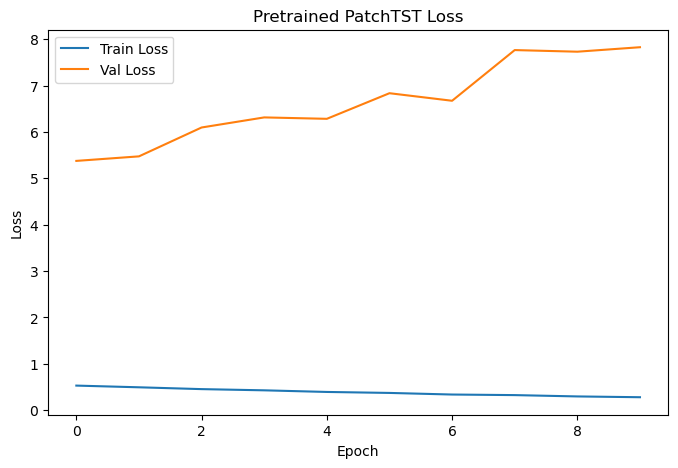

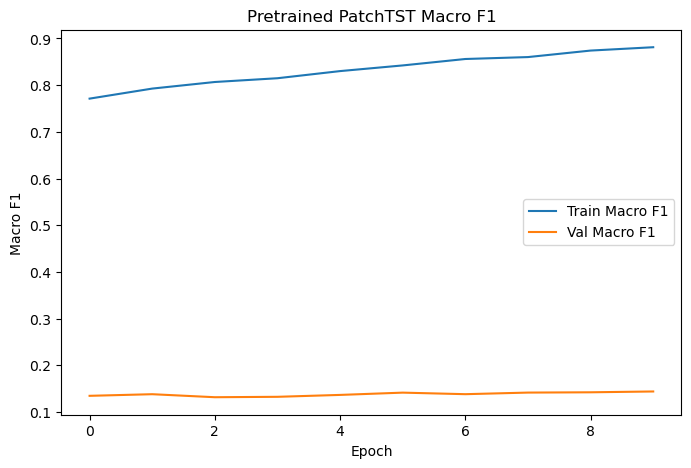

In [65]:
# plot curves
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(result_ft["train_losses"], label="Train Loss")
plt.plot(result_ft["val_losses"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Pretrained PatchTST Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(result_ft["train_f1s"], label="Train Macro F1")
plt.plot(result_ft["val_f1s"], label="Val Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Pretrained PatchTST Macro F1")
plt.legend()
plt.show()

In [66]:
# collect probabilities
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report

def collect_probs_targets(model, loader, device):
    model.eval()

    all_probs = []
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in loader:
            x = batch["past_values"].to(device)
            y = batch["target"].to(device)

            outputs = model(past_values=x)
            logits = outputs.prediction_logits

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

    return np.array(all_probs), np.array(all_preds), np.array(all_targets)

y_val_prob, y_val_pred_base, y_val_true = collect_probs_targets(clf_model, val_loader, device)
y_test_prob, y_test_pred_base, y_test_true = collect_probs_targets(clf_model, test_loader, device)

In [67]:
print("=== Pretrained PatchTST Validation Metrics ===")
print("Accuracy:", accuracy_score(y_val_true, y_val_pred_base))
print("Macro F1:", f1_score(y_val_true, y_val_pred_base, average="macro", zero_division=0))
print("Balanced Accuracy:", balanced_accuracy_score(y_val_true, y_val_pred_base))
print(classification_report(y_val_true, y_val_pred_base, zero_division=0))

=== Pretrained PatchTST Validation Metrics ===
Accuracy: 0.2829646017699115
Macro F1: 0.14395325431425884
Balanced Accuracy: 0.19376602684681338
              precision    recall  f1-score   support

           0       0.10      0.09      0.09       393
           1       0.04      0.06      0.05       159
           2       0.65      0.33      0.44      1891
           3       0.00      0.00      0.00       152
           4       0.39      0.06      0.11      1232
           5       0.00      0.00      0.00        43
           6       0.20      0.81      0.32       650

    accuracy                           0.28      4520
   macro avg       0.20      0.19      0.14      4520
weighted avg       0.42      0.28      0.27      4520



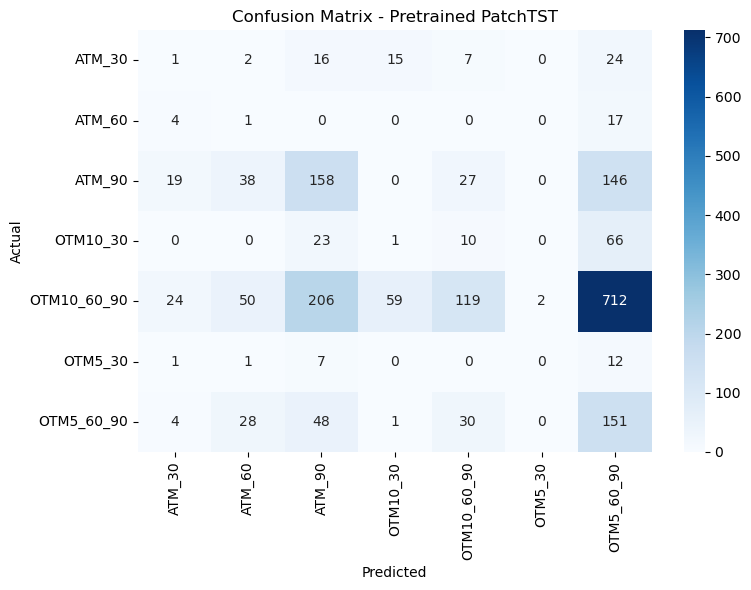

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_true, y_test_pred_base)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Pretrained PatchTST")
plt.tight_layout()
plt.show()

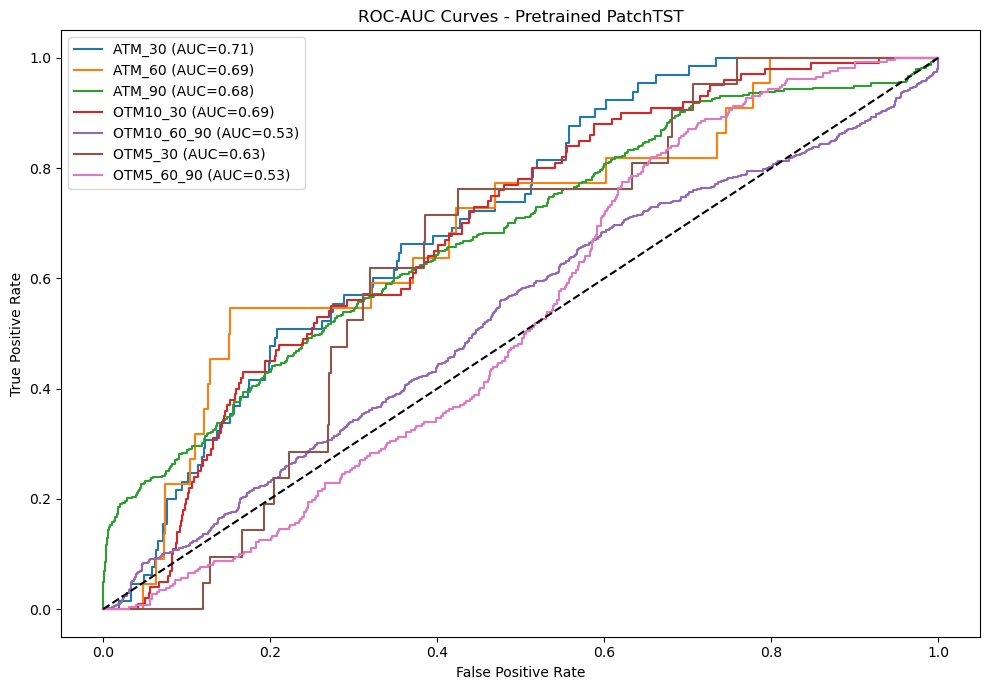

In [69]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

num_classes = len(target_encoder.classes_)
y_test_true_bin = label_binarize(y_test_true, classes=range(num_classes))

plt.figure(figsize=(10, 7))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_true_bin[:, i], y_test_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{target_encoder.classes_[i]} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curves - Pretrained PatchTST")
plt.legend()
plt.tight_layout()
plt.show()

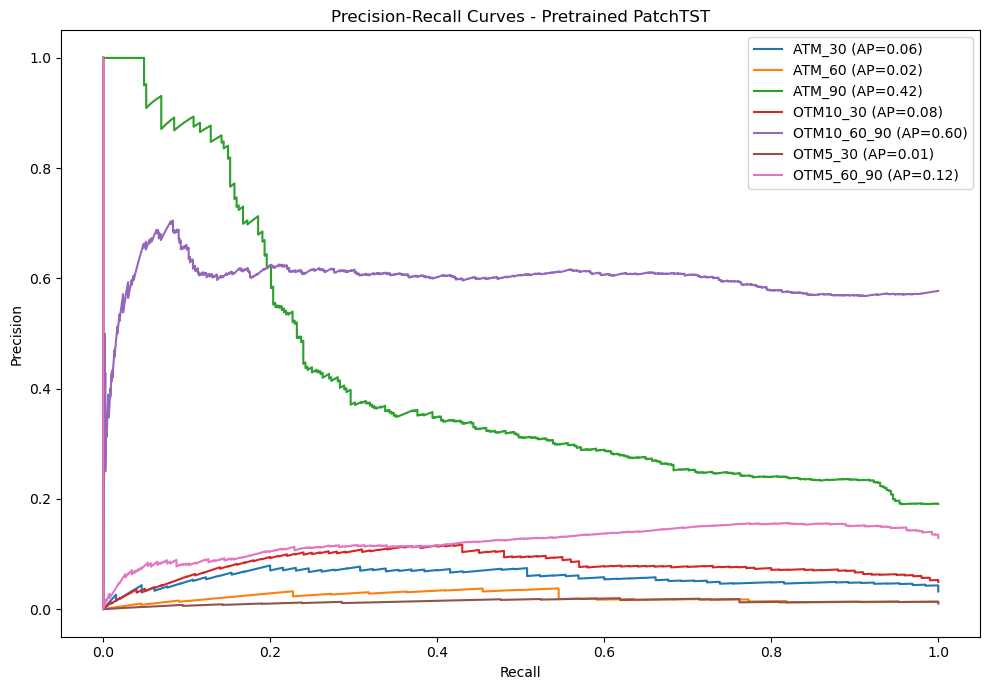

In [70]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_test_true_bin[:, i],
        y_test_prob[:, i]
    )
    ap = average_precision_score(y_test_true_bin[:, i], y_test_prob[:, i])
    plt.plot(recall, precision, label=f"{target_encoder.classes_[i]} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves - Pretrained PatchTST")
plt.legend()
plt.tight_layout()
plt.show()